#0 Environment Setup and Installations

In [ ]:
# 0. Environment Setup and Installations

# 1. Mount Google Drive to access your files
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

# 2. Extract the balanced dataset directly to the working directory
print("Unzipping Balanced Dataset... this might take a few minutes.")
!rm -rf /content/dataset
os.makedirs("/content/dataset", exist_ok=True)
zip_path = "/content/drive/MyDrive/Deepfake_Project/CelebA_HQ_Balanced_ZeroShot.zip"
!unzip -q "{zip_path}" -d "/content/dataset"
print("Unzip complete!")

# 3. Install necessary libraries
print("Installing required libraries...")
!pip install -q transformers accelerate bitsandbytes torch torchvision Pillow tqdm pandas scikit-learn matplotlib seaborn
print("Installations complete! Ready for Data Extraction.")

Mounted at /content/drive
Unzipping Balanced Dataset... this might take a few minutes.
Unzip complete!
Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.1 MB/s eta 0:00:00
Installations complete! Ready for Data Extraction.


#1 copy img from drive

In [ ]:
# 0.5 Define Paths & Data Sanity Check
import os
import glob

# define the paths
real_dir = '/content/dataset/real'
fake_dir = '/content/dataset/fake'

# scan all the images
real_images = glob.glob(f"{real_dir}/*.*")
fake_images = glob.glob(f"{fake_dir}/*.*")

print(" Data Loading Summary:")
print(f" Found {len(real_images)} REAL images.")
print(f" Found {len(fake_images)} FAKE images.")

if len(real_images) == 0 or len(fake_images) == 0:
    print(" ERROR: Missing images! Check your extraction process in Cell 0.")
else:
    print(f" Total: {len(real_images) + len(fake_images)} images accurately loaded and mapped.")

🔍 Data Loading Summary:
📊 Found 17643 REAL images.
📊 Found 17643 FAKE images.
✅ Total: 35286 images accurately loaded and mapped.


#2. Model Initialization


In [ ]:
# --- Model Initialization + Load Fine-Tuned Weights ---

from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(" Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print(" Loading Base Model in bfloat16...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- Load Fine-Tuned Q-Former Weights ---
weights_path = '/content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth'

print(f" Loading Q-Former weights from {weights_path}...")
checkpoint = torch.load(weights_path, map_location=device)

# Load the weights into the Q-former
model.qformer.load_state_dict(checkpoint)
print(" Q-Former weights loaded successfully!")

# --- Freeze everything for Inference ---
# the model just evaluates
for param in model.parameters():
    param.requires_grad = False

model.eval()
print(" Model ready for evaluation!")

🧠 Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/104k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

📦 Loading Q-Former weights from /content/drive/MyDrive/Deepfake_Project/V2_Weights/qformer_finetuned_quality.pth...
✅ Q-Former weights loaded successfully!
✅ Model ready for evaluation!


#3. Dataset Loading

In [ ]:
# 3. Data Pipeline - CelebA-HQ Test Set (Cross-Dataset Evaluation)

import os, glob, torch, pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import multiprocessing

class EvalDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        inputs = self.processor(images=image, text="is this photo real?", return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs['text_label'] = row['label']
        return inputs

# --- Paths ---
fake_dir = '/content/dataset/fake'
real_dir = '/content/dataset/real'

all_paths, all_labels = [], []

def collect_images(folder, label):
    if os.path.exists(folder):
        paths = glob.glob(os.path.join(folder, '*.*'))
        valid = [p for p in paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_paths.extend(valid)
        all_labels.extend([label] * len(valid))
    else:
        print(f" Folder not found: {folder}")

collect_images(fake_dir, "No")
collect_images(real_dir, "Yes")

print(f" Total images found: {len(all_paths)}")

# No train_test_split - entire dataset is test (Cross-Dataset evaluation)
test_df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})
print(f" Test Set size: {len(test_df)} images")

test_dataset = EvalDeepfakeDataset(test_df, processor)

optimal_workers = min(8, multiprocessing.cpu_count())
test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=optimal_workers,
    pin_memory=True,
    prefetch_factor=2
)
print(" Test DataLoader ready!")

📊 Total images found: 35286
✅ Test Set size: 35286 images
🚀 Test DataLoader ready!


#4. Model Evaltauion

In [ ]:
# --- Probabilistic Evaluation Loop + Embeddings Extraction ---

import os
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
from tqdm import tqdm

model.eval()

all_fake_probabilities = []
all_true_numerical_labels = []
all_embeddings = []

yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens  = ["No",  "no",  " No",  " no"]
yes_token_ids = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]
no_token_ids  = [processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]

yes_tensor = torch.tensor(yes_token_ids, device=device)
no_tensor  = torch.tensor(no_token_ids, device=device)

print("🔍 Starting Fine-Tuned Evaluation on CelebA-HQ Test Set...")

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Evaluating"):

        pixel_values           = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids      = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids              = batch['input_ids'].to(device)
        attention_mask         = batch['attention_mask'].to(device)

        text_labels      = batch['text_label']
        numerical_labels = torch.tensor([1 if "no" in label.lower() else 0 for label in text_labels])

        # ── 1. Embeddings extraction ───────────────────────────────────
        qformer_outputs = model.qformer(
            input_ids=qformer_input_ids,
            attention_mask=qformer_attention_mask,
            query_embeds=model.query_tokens.expand(pixel_values.shape[0], -1, -1),
            encoder_hidden_states=model.vision_model(pixel_values).last_hidden_state,
        )
        embedding = qformer_outputs.last_hidden_state.mean(dim=1)
        all_embeddings.extend(embedding.cpu().float().numpy())

        # ── 2. Probabilistic inference ─────────────────────────────────
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        first_token_logits = outputs.scores[0]

        yes_prob = torch.exp(first_token_logits[:, yes_tensor]).sum(dim=1)
        no_prob  = torch.exp(first_token_logits[:, no_tensor]).sum(dim=1)
        fake_probability = no_prob / (yes_prob + no_prob + 1e-8)

        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# ── Metrics & Saving ───────────────────────────────────────────────────────
all_probs  = np.array(all_fake_probabilities)
all_labels = np.array(all_true_numerical_labels)

save_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_CelebAHQ'
os.makedirs(save_dir, exist_ok=True)
np.save(f'{save_dir}/finetuned_probs.npy', all_probs)
np.save(f'{save_dir}/finetuned_labels.npy', all_labels)
np.save(f'{save_dir}/finetuned_embeddings.npy', np.array(all_embeddings))
print(f" Saved to: {save_dir}")

auc_score = roc_auc_score(all_labels, all_probs)
print(f"\n ROC-AUC: {auc_score:.4f}")

thresholds = np.arange(0.1, 0.91, 0.01)
accuracies = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_idx    = np.argmax(accuracies)
best_thresh = thresholds[best_idx]
best_acc    = accuracies[best_idx]

print(f" Optimal Threshold: {best_thresh:.2f}")
print(f" Best Accuracy: {best_acc * 100:.2f}%")

🔍 Starting Fine-Tuned Evaluation on CelebA-HQ Test Set...


Evaluating: 100%|██████████| 1103/1103 [23:40<00:00,  1.29s/it]


💾 Saved to: /content/drive/MyDrive/Deepfake_Project/Eval_Results_CelebAHQ

📊 ROC-AUC: 0.8259
🎯 Optimal Threshold: 0.15
✅ Best Accuracy: 77.73%


#6. Graphs

📊 Calculating Bootstrap Confidence Intervals (1000 iterations)...
✅ Final ROC-AUC: 0.8259 (95% CI: [0.8215, 0.8299])


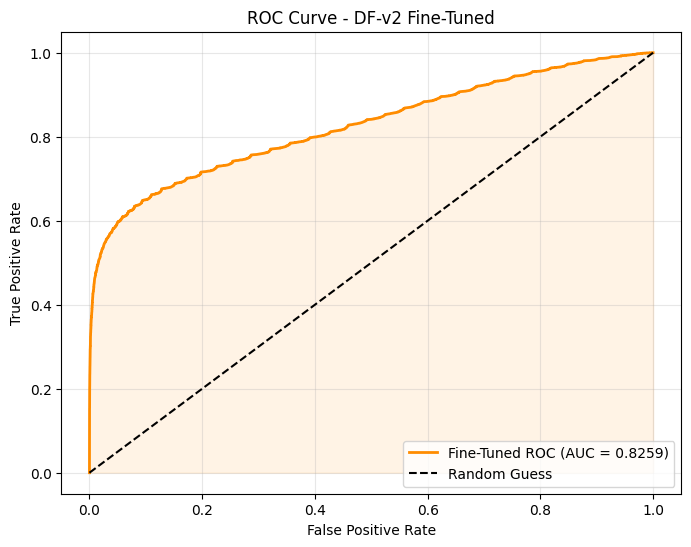

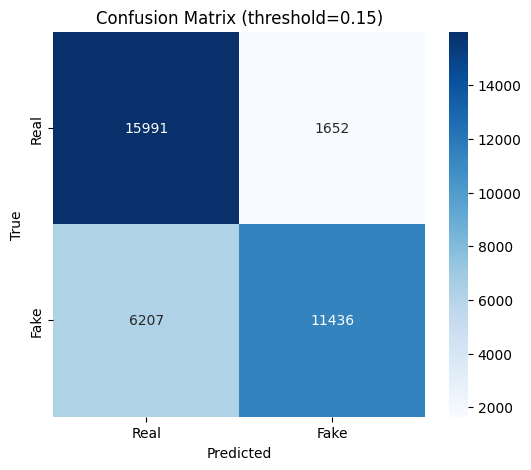

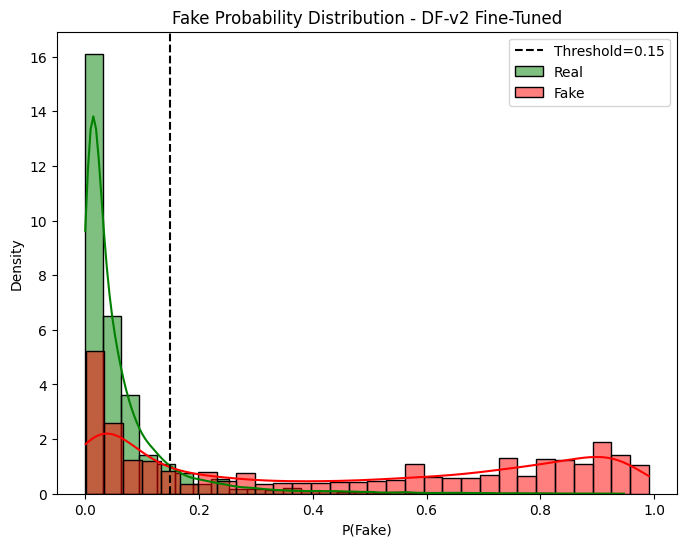

🌌 Generating t-SNE Visualization...
📐 Silhouette Score: 0.0460


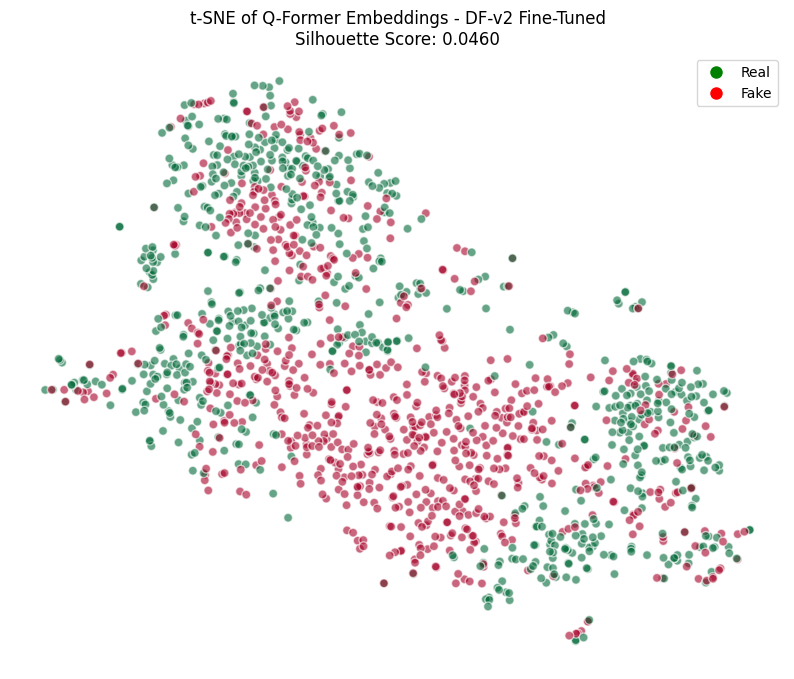


💾 All graphs saved to: /content/drive/MyDrive/Deepfake_Project/Eval_Results_CelebAHQ/Graphs


In [ ]:
# ---. Advanced Metrics & Visualizations ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, silhouette_score, roc_auc_score
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ── Paths ─────────────────────────────────────────────────────────────────
base_results_dir = '/content/drive/MyDrive/Deepfake_Project/Eval_Results_CelebAHQ'
graph_dir = os.path.join(base_results_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)


rng = np.random.RandomState(42)

# ==========================================
# 1. Bootstrap Confidence Intervals (95% CI)
# ==========================================
print(" Calculating Bootstrap Confidence Intervals (1000 iterations)...")
bootstrapped_aucs = []

for _ in range(1000):
    indices = rng.randint(0, len(all_probs), len(all_probs))
    if len(np.unique(all_labels[indices])) < 2:
        continue
    bootstrapped_aucs.append(roc_auc_score(all_labels[indices], all_probs[indices]))

sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f"Final ROC-AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")

# ==========================================
# 2. ROC Curve
# ==========================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Fine-Tuned ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CelebsHQ Fine-Tuned')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. Confusion Matrix
# ==========================================
binary_preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Probability Distribution
# ==========================================
plt.figure(figsize=(8, 6))
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==0],
             color='green', label='Real', kde=True, stat="density", alpha=0.5, bins=30)
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==1],
             color='red',   label='Fake', kde=True, stat="density", alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)')
plt.ylabel('Density')
plt.title('Fake Probability Distribution - DF-v2 Fine-Tuned')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. t-SNE + Silhouette Score
# ==========================================
print("🌌 Generating t-SNE Visualization...")
sample_size = min(1500, len(all_embeddings))
indices = rng.choice(len(all_embeddings), sample_size, replace=False)
sampled_embeddings = np.array(all_embeddings)[indices]
sampled_labels     = all_labels[indices]

sil_score = silhouette_score(sampled_embeddings, sampled_labels)
print(f"📐 Silhouette Score: {sil_score:.4f}")

embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sampled_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=sampled_labels, cmap=plt.cm.RdYlGn_r, alpha=0.6, edgecolors='w', s=40)
custom_lines = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10)]
plt.legend(custom_lines, ['Real', 'Fake'])
plt.title(f't-SNE of Q-Former Embeddings - DF-v2 Fine-Tuned\nSilhouette Score: {sil_score:.4f}')
plt.axis('off')
plt.savefig(os.path.join(graph_dir, 'tsne_finetuned.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 All graphs saved to: {graph_dir}")